In [2]:
from scripts.AbstractExperiments import ExperimentRunner, GenerateConfigs
from EnvironmentBuilder.SearchRescue.Rescue import Rescue
import EnvironmentBuilder.SearchRescue.Drawing as SearchRescueDraw
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import math
from matplotlib.ticker import MaxNLocator
from scripts.Plotting import *

plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"


def GenerateTeamConfigs(teams_:list, name_prefix=None):
    configs = {}
    if name_prefix is None:
        name_prefix = f"{len(teams_)}_"
    # Act-Utilitarianism
    con = {"Theories": [["AU", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", "AU"])
    configs[f"{name_prefix}Act-Utilitarianism"] = con

    # Balance
    con = {"Theories": [], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", f"{t}"])
    configs[f"{name_prefix}Separate Theories"] = con

    # Fairness
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair"]])
    configs[f"{name_prefix}Fairness"] = con

    # Fairness + Others
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{name_prefix}Fairness + Separate"] = con

    # Fairness + Act-Utilitarianism
    con = {"Theories": [["Fair", "Fairness", 0], ["AU", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["AU", "Fair"]])
    configs[f"{name_prefix}Fairness + AU"] = con

    # Rawls
    con = {"Theories":[["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls"]])
    configs[f"{name_prefix}Rawls"] = con

    # Rawls + Others
    con = {"Theories": [["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Rawls"]])
    configs[f"{name_prefix}Rawls + Separate"] = con

    # Rawls + AU
    con = {"Theories": [["Rawls", "Maximin", 0], ["AU", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls", "AU"]])
    configs[f"{name_prefix}Rawls + AU"] = con

    return configs

def MakeTeamWeights(teams_):
    p = [2**i for i in range(0, len(teams_))]
    total = sum(p)
    w = [i / total for i in p]
    o = {}
    for t in teams_:
        for i, t in enumerate(teams_):
            o[f"{t}_hosp_success"] = w[i]
    return o

markers = {
    "Separate Theories": "o",
    "Act-Utilitarianism": "s",
    "Fairness": "^",
    "Rawls": "*",
    "Fair + balance": ".",
    "Rawls + balance": "x"
}
colours = {
    "Separate Theories": "blue",
    "Act-Utilitarianism": "black",
    "Fairness": "green",
    "Rawls": "red",
    "Fair + balance": "cyan",
    "Rawls + balance": "magenta",
}

configurations = [
    "Act-Utilitarianism",
    "Fairness",
    "Rawls",
    "Separate Theories",
    "Fairness + AU",
    "Rawls + AU",
    "Fairness + Separate",
    "Rawls + Separate"
]
a = 0.7
styles = {
    "Act-Utilitarianism":   dict(linestyle="solid", marker="^", color="black", alpha=0.5),
    "Fairness":             dict(linestyle=":", marker="o", color="green", alpha=0.5),
    "Rawls":                dict(linestyle="-.", marker="o", color="red", alpha=0.5),
    "Separate Theories":    dict(linestyle="-", marker="x", color="blue", alpha=a),

    "Fairness + AU":        dict(linestyle=":", marker="^", color="green", alpha=a),
    "Rawls + AU":           dict(linestyle="-.", marker="^", color="red", alpha=a),
    "Fairness + Separate":  dict(linestyle=":", marker="x", color="green", alpha=a),
    "Rawls + Separate":     dict(linestyle="-.", marker="x", color="red", alpha=a),
}

In [ ]:
env_reps = 10
configs = []
lo_horizon, hi_horizon = 3, 8
lo_comms, hi_comms = 1, 4
lo_depth, hi_depth = 0, 5
for horizon_ in range(lo_horizon, hi_horizon):
    for Comms in range(lo_comms, hi_comms):
        for d in range(lo_depth, hi_depth):
            teams = [f"{i}" for i in range(Comms)]
            odds = MakeTeamWeights(teams)
            configs += GenerateConfigs(
                inputConfigs=GenerateTeamConfigs(
                    teams,
                    name_prefix=f"c{len(teams)}_h{horizon_}_d{d}_"
                ),
                defaultConfig={
                    "Horizon": horizon_,
                    "Teams": teams, 
                    "unknown_depth": d,
                    "Odds": odds
                }
            )

er = ExperimentRunner("Rescue", configs, outFolder="Profile_Search")

In [5]:
# 3.7s
_ = er.buildEnvironments()

Written Rescue MMMDP with 8 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Profile_Search/mdps/c1_h3_d0_Act-Utilitarianism_con0.json

Written Rescue MMMDP with 8 states and theories [{'Name': '0', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Profile_Search/mdps/c1_h3_d0_Separate Theories_con0.json

Written Rescue MMMDP with 8 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Profile_Search/mdps/c1_h3_d0_Fairness_con0.json

Written Rescue MMMDP with 8 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}, {'Name': '0', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Profile_Search/m

In [6]:
# env_rep 10 = 4min 24s
er.runPlanner(envRepetitions=env_reps, debug_level=2)

Start 1/6000 -- /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Profile_Search/mdps/c1_h3_d0_Act-Utilitarianism_con0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
Finished Building Heuristic in 6 microseconds.
Finished Planning in 9 microseconds
Extracted 1 policies in 34 microseconds.
Finished MEHR in 0 microseconds.
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Profile_Search/raw/c1_h3_d0_Act-Utilitarianism_con0_rep0.json' created successfully!
Start 2/6000 -- /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Profile_Search/mdps/c1_h3_d0_Act-Utilitarianism_con0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
Finished Building Heuristic in 5 microseconds.
Finished Planning in 8 microseconds
Extracted 1 policies in 23 microseconds.
Finished MEHR in 0 microseconds.
JSON file '/home/psiko/Program

In [4]:
er.extractData(1, env_reps)
df = pd.DataFrame(er.data)
df = df.drop(labels=['Configuration Repetition', 'Theories', 'Considerations', 'CQ1 Time', 'CQ2 Time', 'Output Time', 'Solution Reduction Time'], axis=1)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)
# ------------------------------------------------------------
# Extract environment parameters BEFORE changing Configuration
# ------------------------------------------------------------
df["communities"] = pd.to_numeric(
    df["Configuration"].str.extract(r"c(\d+)", expand=False),
    errors="coerce"
)
df["Horizon"] = pd.to_numeric(
    df["Configuration"].str.extract(r"_h(\d+)", expand=False),
    errors="coerce"
)
df["unknown_depth"] = pd.to_numeric(
    df["Configuration"].str.extract(r"_d(\d+)", expand=False),
    errors="coerce"
)
df['Configuration'] = df['Configuration'].str.split("_", n=3).str[-1]
df.head(500)

df["Horizon_x_depth"] = df["Horizon"] * df["unknown_depth"] 

TIMING_COLUMNS = [
    "Total Time",
    "Heuristic Time",
    "Planning Time",
    "Solution Extraction Time",
    "MEHR Time",
]
df

,Configuration,Environment Repetition,Total Time,Heuristic Time,Planning Time,Solution Extraction Time,MEHR Time,Expanded States,BSG States,Average Histories,...,Number of Minimal Non-Acceptability Policies,Number of Solutions,Total Attacks,Total Reachable Policies,0:wellbeing,1:wellbeing,2:wellbeing,communities,unknown_depth,Horizon_x_depth
0,Act-Utilitarianism,0,49,6,9,34,0,6,8,3,...,1,1,0,5,2,NaN,NaN,1,0,0
1,Act-Utilitarianism,1,36,5,8,23,0,6,8,3,...,1,1,0,5,2,NaN,NaN,1,0,0
2,Act-Utilitarianism,2,38,5,8,25,0,6,8,3,...,1,1,0,5,2,NaN,NaN,1,0,0
3,Act-Utilitarianism,3,43,5,8,30,0,6,8,3,...,1,1,0,5,2,NaN,NaN,1,0,0
4,Act-Utilitarianism,4,44,6,10,28,0,6,8,3,...,1,1,0,5,2,NaN,NaN,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,Rawls + AU,5,206609,132,200921,4537,1019,143,290,19,...,2,42,2293,-3264118685631612203,1.125,1.2679,1.125,3,4,28
5996,Rawls + AU,6,207269,145,201544,4564,1016,143,290,19,...,2,42,2293,-3264118685631612203,1.125,1.2679,1.125,3,4,28
5997,Rawls + AU,7,212043,183,206246,4557,1057,143,290,19,...,2,42,2293,-3264118685631612203,1.125,1.2679,1.125,3,4,28
5998,Rawls + AU,8,207692,136,202011,4524,1021,143,290,19,...,2,42,2293,-3264118685631612203,1.125,1.2679,1.125,3,4,28


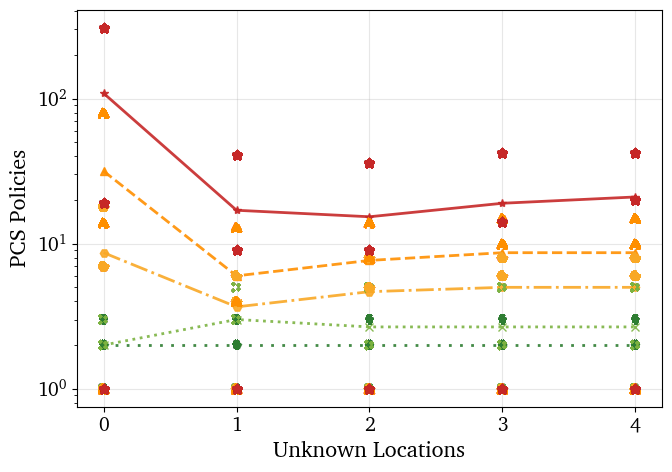

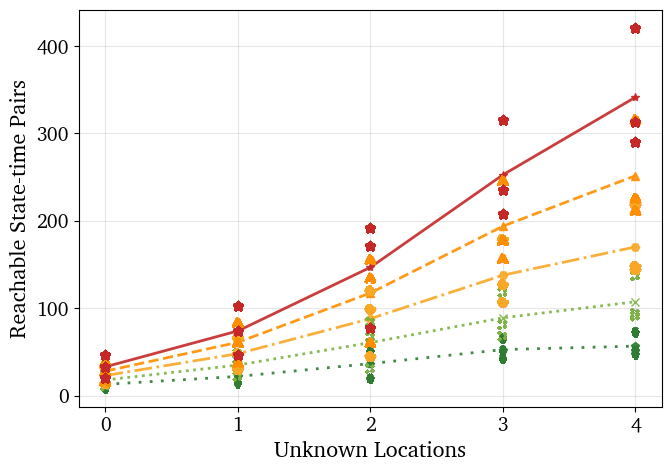

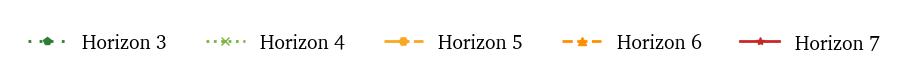

(<Figure size 700x8 with 1 Axes>, <Axes: >)

In [11]:
temp_df = df.copy()
temp_df["Configuration"] = "All"
temp_cons = ["All"]
styles = {
    3: {'marker':'p', 'linewidth':2, 'color': '#2e7d32', 'linestyle': (0, (1, 3))},
    4: {'marker':'x', 'linewidth':2, 'color': '#7cb342', 'linestyle': ':'},
    5: {'marker':'H', 'linewidth':2, 'color': '#f9a825', 'linestyle': '-.'},
    6: {'marker':'^', 'linewidth':2, 'color': '#ff8f00', 'linestyle': '--'},
    7: {'marker':'*', 'linewidth':2, 'color': '#c62828', 'linestyle': '-'},
}

MultiLinePlotGraph(temp_df,
                group_var="Horizon",
                group_labels= [f"Horizon {i}" for i in range(lo_horizon,hi_horizon)],
                independent_var="unknown_depth",
                ind_label="Unknown Locations",
                dependent_var="Number of Solutions",
                dep_label="PCS Policies",
                no_legend=True,
                styles=styles,
                plot_scatter_line=True,
                fit_legend_mode="inline",
                legend_loc="upper right",
                legend_in_axes=True,
                fit_legend_loc=None,
                bbox_to_anchor=(0.95,0.9),
                legend_cols = 1,
                xtick_step=1,
                log_scale=True,
                scatter_all_points=True,
                fig_size=(7,5),
                file_out=f"{er.figuresFolder}/Depth_V_PCS.pdf")

MultiLinePlotGraph(temp_df,
                group_var="Horizon",
                group_labels= [f"Horizon {i}" for i in range(lo_horizon,hi_horizon)],
                independent_var="unknown_depth",
                ind_label="Unknown Locations",
                dependent_var="Total States",
                dep_label="Reachable State-time Pairs",
                legend_title="Unknown Depth",
                styles=styles,
                plot_scatter_line=True,
                scatter_all_points=True,
                legend_loc="upper left",
                no_legend=True,
                xtick_step=1,
                log_scale=False,
                fig_size=(7,5),
                file_out=f"{er.figuresFolder}/Depth_V_StateTimes.pdf")

MultiLinePlotGraph(temp_df,
                group_var="Horizon",
                group_labels= [f"Horizon {i}" for i in range(lo_horizon,hi_horizon)],
                independent_var="unknown_depth",
                ind_label="Unknown Locations",
                dependent_var="Total States",
                dep_label="Reachable State-time Pairs",
                legend_title=None,
                styles=styles,
                plot_scatter_line=True,
                legend_loc="upper left",
                legend_in_axes=True,
                fit_legend_loc=None,
                bbox_to_anchor=(0,0),
                legend_only=True,
                legend_cols=5,
                xtick_step=1,
                log_scale=False,
                fig_size=(7,0.08),
                file_out=f"{er.figuresFolder}/Horizon_Legend.pdf")

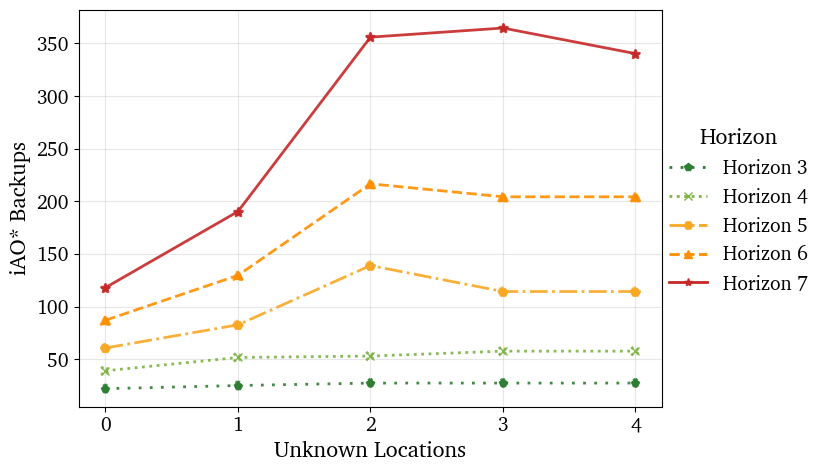

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='Unknown Locations', ylabel='iAO* Backups'>)

In [13]:
MultiLinePlotGraph(temp_df,
                group_var="Horizon",
                group_labels= [f"Horizon {i}" for i in range(lo_horizon,hi_horizon)],
                independent_var="unknown_depth",
                ind_label="Unknown Locations",
                dependent_var="Backups",
                dep_label="iAO* Backups",
                legend_title="Horizon",
                styles=styles,
                plot_scatter_line=True,
                fit_legend_mode="inline",
                legend_loc="upper left",
                legend_in_axes=True,
                fit_legend_loc=None,
                bbox_to_anchor=(0.95,0.75),
                legend_cols = 1,
                xtick_step=1,
                log_scale=False,
                fig_size=(7,5),
                file_out=f"{er.figuresFolder}/Depth_V_Backups.pdf")


<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_56809/1809616265.py:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  dep_label="Total CPU Time ($\mu$s)",
/tmp/ipykernel_56809/1809616265.py:32: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw

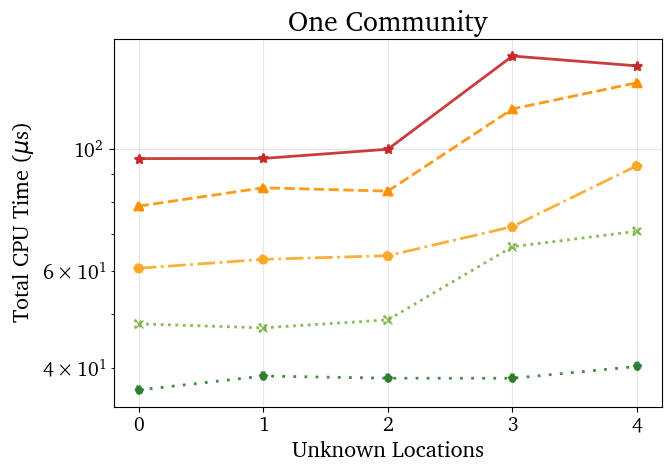

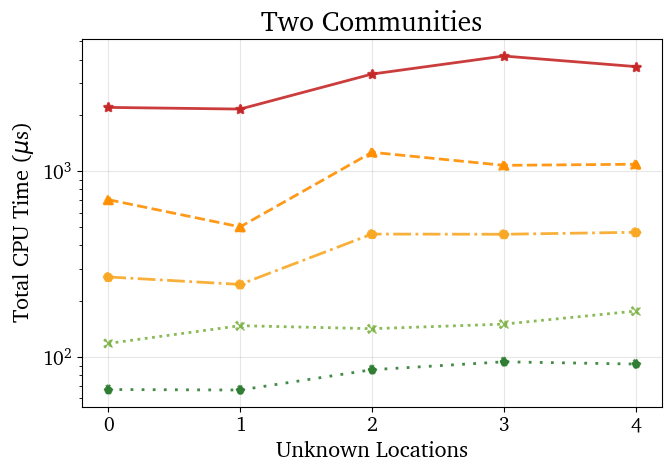

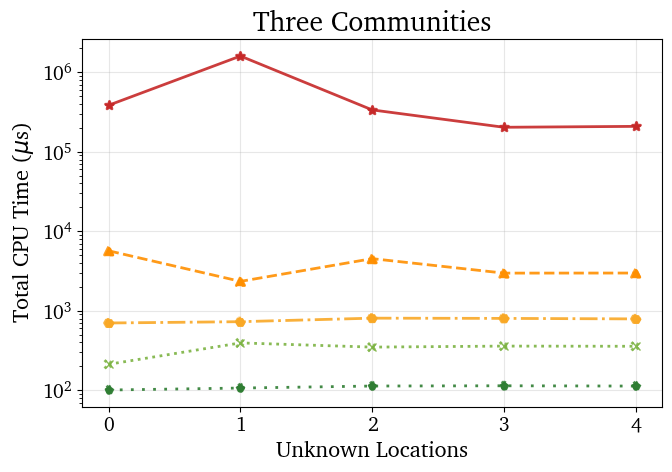

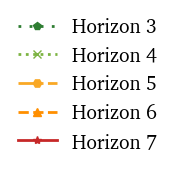

(<Figure size 10x10 with 1 Axes>, <Axes: >)

In [10]:
temp_df = df.copy()
titles = ["One Community", "Two Communities", "Three Communities"]
for i, com in enumerate(range(lo_comms, hi_comms)):
    temp_df = df[df["communities"]==com].copy()
    MultiLinePlotGraph(temp_df,
                group_var="Horizon",
                group_labels= [f"Horizon {i}" for i in range(lo_horizon,hi_horizon)],
                title=titles[i],
                independent_var="unknown_depth",
                ind_label="Unknown Locations",
                xtick_step=1,
                dependent_var="Total Time",
                dep_label="Total CPU Time ($\mu$s)",
                styles=styles,
                fit_legend_mode="inline",
                legend_loc="center right",
                no_legend=True,
                fig_size=(7,5),
                legend_cols = 1,
                plot_scatter_line=True,
                file_out=f"{er.figuresFolder}/Depth_V_Time_Com_{com}.pdf")
    
MultiLinePlotGraph(temp_df,
                group_var="Horizon",
                group_labels= [f"Horizon {i}" for i in range(lo_horizon,hi_horizon)],
                title=titles[i],
                independent_var="unknown_depth",
                ind_label="Unknown Locations",
                xtick_step=1,
                legend_only=True,
                dependent_var="Total Time",
                dep_label="Total CPU Time ($\mu$s)",
                legend_title=None,
                styles=styles,
                fit_legend_mode="inline",
                legend_loc="center right",
                no_legend=True,
                fig_size=(0.1,0.1),
                legend_cols = 1,
                plot_scatter_line=True,
                file_out=f"{er.figuresFolder}/Vertical_Horizon_Legend.pdf")

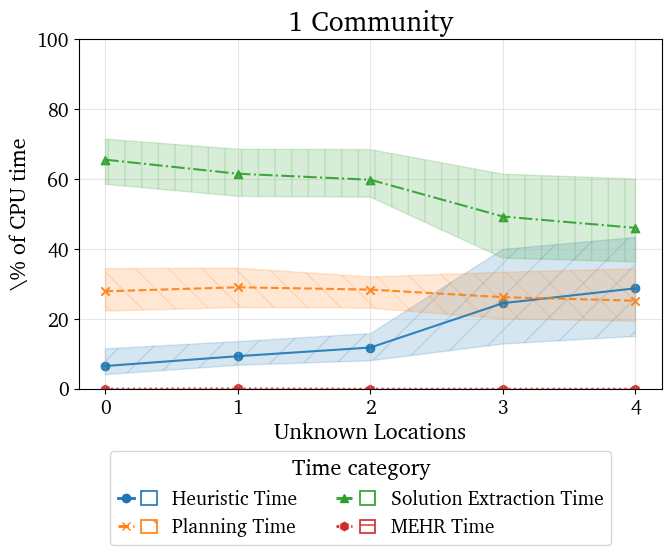

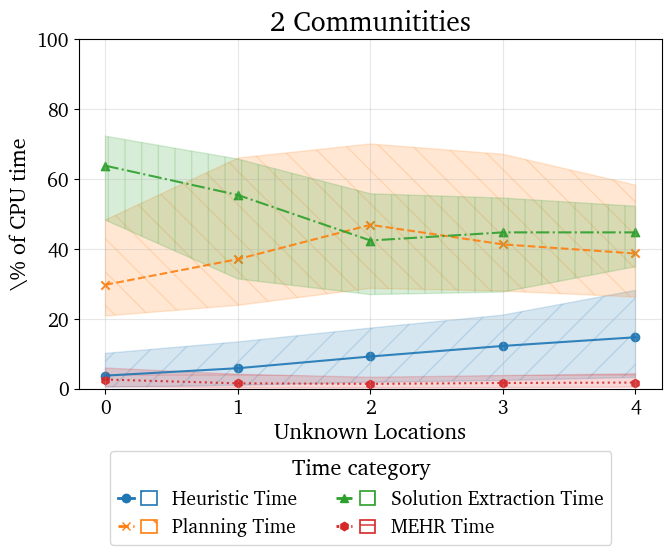

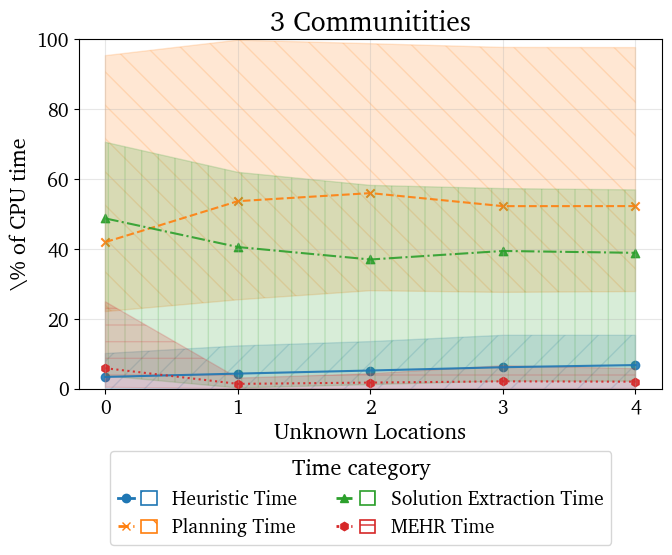

In [8]:
for com in range(lo_comms, hi_comms):
    temp_df = df[df["communities"]==com].copy()
    temp_df['Configuration'] = 'All'
    temp_df = temp_df[temp_df['Configuration']=='All']
    l = f"{com} Communitities"
    if com==1:
        l = "1 Community"
    mean_time_graph(temp_df, 'All', dep_var='unknown_depth', dep_var_label="Unknown Locations",
                title=l, legend_bbox_to_anchor=(0.93,-0.15),
                    fig_size=(7,6), legend_cols=2,
                    ci=0.95, plot_points='mean')